In [1]:
# Core Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn  Utilities

from sklearn.preprocessing import LabelEncoder

# Set a style for plots
sns.set_style("whitegrid")

---------------
Load the "drivers_final2_df.csv" dataset as crash_df.

In [2]:
crash_df = pd.read_csv(
    "https://raw.githubusercontent.com/Alissa-Ouspen/data201_alissa/main/final/drivers_final3_df.csv",
    dtype={'medication_use': str}
)

# To avoid slowing processing speed, specify data type for
# column 35 (medication_use) as str

In [3]:
columns_to_analyze = ['Vehicle_Num', 'Collision_Type', 'Weather',
       'Surface_Condition', 'Ambient_Light', 'Driver_At_Fault',
       'Injury_Severity', 'Drivers_License_State',
       'Vehicle_Damage', 'Speed_Limit',
        'Junction', 'Intersection_Type',
        'Road_Condition', 'Crash_Hour', 'Crash_Month',
       'Vehicle_Age', 'alc_drug_med', 'Driver_Distract_YN']

crash_analysis_df = crash_df[columns_to_analyze].copy()

#crash_analysis_df.head()

Fields_to_analyze_table
--------------------------------------------------------------------
--------------------------------------------------------------------
| Field                      | count  | dtype          | to_analyze |
|:---------------------------|:-------|:---------------|:-----------|
| Vehicle_Num                | 214273 | index int         |  yes       |
| Collision_Type             | 6      | cat        |     consider       |
| Weather                    | 9      | cat        |     consider       |
| Surface_Condition          | 11     | cat         |    consider       |
| Ambient_Light              | 5      | cat         |      consider      |
| Driver_At_Fault            | 2      | cat   DV?    |      yes      |
| Injury_Severity            | 5      | cat   DV?     |     yes       |
| Drivers_License_State      | 55     | cat        |    no        |
| Vehicle_Damage             | 6      | cat  DV?      |     yes       |
| Speed_Limit                | 16     | numeric int         |   yes         |
| Junction                   | 10     | cat       |       consider     |
| Intersection_Type          | 7      | cat        |        consider    |
| Road_Condition             | 8      | cat        |       consider     |
| Crash_Hour                 | 24     | numeric int  IV       |    yes        |
| Crash_Month                | 12     | numeric int  IV      |      yes      |
| alc_drug_med             | 3      | cat         |        yes    |
| Vehicle_Age                | 67     | numeric int  IV        |     yes       |
| Driver_Distract_YN         | 3     | cat       |     yes       |


Variables of interest:  Surface_Condition, Ambient_Light, and Weather.  
Need to quantify.



In [5]:
print(crash_analysis_df["Surface_Condition"].unique())
print(crash_analysis_df["Ambient_Light"].unique())
print(crash_analysis_df["Weather"].unique())

['Dry' nan 'Wet' 'Water (standing, moving)' 'Ice/Frost' 'Slush' 'Snow'
 'Mud, Dirt, Gravel' 'Oil' 'Sand' 'ICE' 'WATER(STANDING/MOVING)']
['Dark - Lighted' 'Dark' 'Daylight' 'Dusk' 'Dawn' nan]
['Clear' 'Rain' 'Cloudy' nan 'Fog, Smog, Smoke'
 'Freezing Rain Or Freezing Drizzle' 'Snow/ Sleet/ Hail'
 'Severe Crosswinds' 'Blowing Sand, Soil, Dirt' 'SEVERE WINDS']


Surface_hazard_encoded:  
Dry: 0
['Wet', 'Water (standing, moving)', 'WATER(STANDING/MOVING)','Mud, Dirt, Gravel', 'Sand'] 🇰: 1
['Ice/Frost' 'Slush' 'Snow' 'Oil'  'ICE' ] : 2

Light_hazard_encoded:
'Daylight' :0
'Dusk' 'Dawn': 1
'Dark - Lighted':2
'Dark':3

Weather_hazard_encoded:
'Clear': 0
'Cloudy': 1
'Rain' :2
'Fog, Smog, Smoke': 3
'Severe Crosswinds' 'SEVERE WINDS' 'Blowing Sand, Soil, Dirt': 4
'Snow/ Sleet/ Hail' 'Freezing Rain Or Freezing Drizzle'  : 5



#### Encode Injury_Severity and Vehicle_Damage

into numerical representations using these mappings:

*   **Injury_Severity:**
    *   "No Apparent Injury" as 0
    *   "Suspected Minor Injury" as 1
    *   "Possible Injury" as 2
    *   "Suspected Serious Injury" as 3
    *   "Fatal Injury" as 4

*   **Vehicle_Damage:**
    *   "Vehicle Not at Scene" as NaN
    *   "No Damage" as 0
    *   "Superficial" as 1
    *   "Functional" as 2
    *   "Disabling" as 3
    *   "Destroyed" as 4

In [ ]:
# Define the mapping for Injury_Severity
injury_severity_mapping = {
    'No Apparent Injury': 0,
    'Suspected Minor Injury': 1,
    'Possible Injury': 2,
    'Suspected Serious Injury': 3,
    'Fatal Injury': 4
}

# Apply the mapping to the 'Injury_Severity' column
crash_analysis_df['Injury_Severity_Encoded'] = crash_analysis_df['Injury_Severity'].map(injury_severity_mapping)

# Define the mapping for Vehicle_Damage
vehicle_damage_mapping = {
    'No Damage': 0,
    'Superficial': 1,
    'Functional': 2,
    'Disabling': 3,
    'Destroyed': 4
}
# replace 'Vehicle Not at Scene' with NaN
crash_analysis_df['Vehicle_Damage_Encoded'] = crash_analysis_df['Vehicle_Damage'].replace('Vehicle Not at Scene', np.nan)
# apply the numerical mapping
crash_analysis_df['Vehicle_Damage_Encoded'] = crash_analysis_df['Vehicle_Damage_Encoded'].map(vehicle_damage_mapping)

print("Encoded 'Injury_Severity' unique values and counts:")
print(crash_analysis_df['Injury_Severity_Encoded'].value_counts(dropna=False))

print("\nEncoded 'Vehicle_Damage' unique values and counts:")
print(crash_analysis_df['Vehicle_Damage_Encoded'].value_counts(dropna=False))

Encoded 'Injury_Severity' unique values and counts:
Injury_Severity_Encoded
0.0    173638
2.0     20314
1.0     15411
NaN      2974
3.0      1738
4.0       198
Name: count, dtype: int64

Encoded 'Vehicle_Damage' unique values and counts:
Vehicle_Damage_Encoded
3.0    79964
1.0    55186
2.0    54644
NaN    10178
4.0     7610
0.0     6691
Name: count, dtype: int64


#### Encode Surface_Condition, Ambient_Light, and Weather into numerical representations using these mappings:

In [6]:
# Define the mapping for Surface_Condition
surface_condition_mapping = {
    'Dry': 0,
    'Wet': 1,
    'Water (standing, moving)': 1,
    'WATER(STANDING/MOVING)': 1,
    'Mud, Dirt, Gravel': 1,
    'Sand': 1,
    'Ice/Frost': 2,
    'Slush': 2,
    'Snow': 2,
    'Oil': 2,
    'ICE': 2
}
crash_analysis_df['Surface_Condition_Encoded'] = crash_analysis_df['Surface_Condition'].map(surface_condition_mapping)

# Define the mapping for Ambient_Light
ambient_light_mapping = {
    'Daylight': 0,
    'Dusk': 1,
    'Dawn': 1,
    'Dark - Lighted': 2,
    'Dark': 3
}
crash_analysis_df['Ambient_Light_Encoded'] = crash_analysis_df['Ambient_Light'].map(ambient_light_mapping)

# Define the mapping for Weather
weather_mapping = {
    'Clear': 0,
    'Cloudy': 1,
    'Rain': 2,
    'Fog, Smog, Smoke': 3,
    'Severe Crosswinds': 4,
    'SEVERE WINDS': 4,
    'Blowing Sand, Soil, Dirt': 4,
    'Snow/ Sleet/ Hail': 5,
    'Freezing Rain Or Freezing Drizzle': 5
}
crash_analysis_df['Weather_Encoded'] = crash_analysis_df['Weather'].map(weather_mapping)

print("Encoded 'Surface_Condition' unique values and counts:")
print(crash_analysis_df['Surface_Condition_Encoded'].value_counts(dropna=False))

print("\nEncoded 'Ambient_Light' unique values and counts:")
print(crash_analysis_df['Ambient_Light_Encoded'].value_counts(dropna=False))

print("\nEncoded 'Weather' unique values and counts:")
print(crash_analysis_df['Weather_Encoded'].value_counts(dropna=False))

Encoded 'Surface_Condition' unique values and counts:
Surface_Condition_Encoded
0.0    151756
1.0     34391
NaN     25132
2.0      2994
Name: count, dtype: int64

Encoded 'Ambient_Light' unique values and counts:
Ambient_Light_Encoded
0.0    145384
2.0     49425
1.0      8424
3.0      8261
NaN      2779
Name: count, dtype: int64

Encoded 'Weather' unique values and counts:
Weather_Encoded
0.0    149986
2.0     24774
1.0     21011
NaN     14707
5.0      2814
3.0       775
4.0       206
Name: count, dtype: int64


#### Encode `alc_drug_med` and `Driver_Distract_YN` into numerical representations

In [8]:
# Define the mapping for 'alc_drug_med'
alc_drug_med_mapping = {
    'No': 0,
    'Yes': 1
}
crash_analysis_df['substance_encoded'] = crash_analysis_df['alc_drug_med'].map(alc_drug_med_mapping)

# Define the mapping for 'Driver_Distract_YN'
driver_distract_yn_mapping = {
    'No': 0,
    'Yes': 1
}
crash_analysis_df['distract_encoded'] = crash_analysis_df['Driver_Distract_YN'].map(driver_distract_yn_mapping)

print("Encoded 'alc_drug_med' unique values and counts:")
print(crash_analysis_df['substance_encoded'].value_counts(dropna=False))

print("\nEncoded 'Driver_Distract_YN' unique values and counts:")
print(crash_analysis_df['distract_encoded'].value_counts(dropna=False))

Encoded 'alc_drug_med' unique values and counts:
substance_encoded
NaN    170921
0.0     36007
1.0      7345
Name: count, dtype: int64

Encoded 'Driver_Distract_YN' unique values and counts:
distract_encoded
0.0    134589
NaN     46101
1.0     33583
Name: count, dtype: int64


#### Create 'injury_encoded' and 'veh_damage_encode' from existing encoded columns

In [12]:
# Define the mapping for Injury_Severity
injury_severity_mapping = {
    'No Apparent Injury': 0,
    'Suspected Minor Injury': 1,
    'Possible Injury': 2,
    'Suspected Serious Injury': 3,
    'Fatal Injury': 4
}

# Apply the mapping to the 'Injury_Severity' column
crash_analysis_df['Injury_Severity_Encoded'] = crash_analysis_df['Injury_Severity'].map(injury_severity_mapping)

# Define the mapping for Vehicle_Damage
vehicle_damage_mapping = {
    'No Damage': 0,
    'Superficial': 1,
    'Functional': 2,
    'Disabling': 3,
    'Destroyed': 4
}
# replace 'Vehicle Not at Scene' with NaN
crash_analysis_df['Vehicle_Damage_Encoded'] = crash_analysis_df['Vehicle_Damage'].replace('Vehicle Not at Scene', np.nan)
# apply the numerical mapping
crash_analysis_df['Vehicle_Damage_Encoded'] = crash_analysis_df['Vehicle_Damage_Encoded'].map(vehicle_damage_mapping)

# Create 'injury_encoded' from 'Injury_Severity_Encoded'
crash_analysis_df['injury_encoded'] = crash_analysis_df['Injury_Severity_Encoded']

# Create 'veh_damage_encode' from 'Vehicle_Damage_Encoded'
crash_analysis_df['veh_damage_encode'] = crash_analysis_df['Vehicle_Damage_Encoded']

print("Created 'injury_encoded' and 'veh_damage_encode' columns.")
print("Value counts for 'injury_encoded':")
print(crash_analysis_df['injury_encoded'].value_counts(dropna=False))
print("\nValue counts for 'veh_damage_encode':")
print(crash_analysis_df['veh_damage_encode'].value_counts(dropna=False))

Created 'injury_encoded' and 'veh_damage_encode' columns.
Value counts for 'injury_encoded':
injury_encoded
0.0    173638
2.0     20314
1.0     15411
NaN      2974
3.0      1738
4.0       198
Name: count, dtype: int64

Value counts for 'veh_damage_encode':
veh_damage_encode
3.0    79964
1.0    55186
2.0    54644
NaN    10178
4.0     7610
0.0     6691
Name: count, dtype: int64


#### Re-saving the DataFrame with all encoded columns

In [13]:
# Define the file path for the CSV
output_file_path = 'encoded_crash_data.csv'

# Save the DataFrame to a CSV file
crash_analysis_df.to_csv(output_file_path, index=False)

print(f"Encoded data saved to {output_file_path}")

Encoded data saved to encoded_crash_data.csv


#### Save the encoded data to a CSV file

In [9]:
# Define the file path for the CSV
output_file_path = 'encoded_crash_data.csv'

# Save the DataFrame to a CSV file
crash_analysis_df.to_csv(output_file_path, index=False)

print(f"Encoded data saved to {output_file_path}")

Encoded data saved to encoded_crash_data.csv


You can then download this file from your Colab environment or save it to Google Drive. To load it in another Colab notebook, you would typically upload the file and then use `pd.read_csv()`:

```python
import pandas as pd

# Assuming the file is uploaded to the Colab environment
loaded_df = pd.read_csv('encoded_crash_data.csv')
display(loaded_df.head())
```

-------------
####Prepare data for Analysis by encoding data
(Yes to 1, No to 0)
Since the dataset is so large, we can afford to drop rows where data for  
any of the three variables are missing (NaN).  

#####**Idea for future research question:**  
does dropping the NaN data from the training set provide better or worse prediction  
outcomes as compared to substituting the mode of that column for the NaN?

In [ ]:
# Identify the columns to consider for dropping NaNs
relevant_cols = ['alc_drug_med', 'Driver_Distract_YN', \
                 'Driver_At_Fault', "Injury_Severity_Encoded", \
                 "Vehicle_Damage_Encoded", "Speed_Limit"]

# Drop rows where any of the relevant columns have NaN values from crash_analysis_df
# Use .copy() to ensure use of separate DataFrame, avoid SettingWithCopyWarning
cleaned_crash_df = crash_analysis_df.dropna(subset=relevant_cols).copy()

# Define features (X) and target (y) from the cleaned_crash_df
X = cleaned_crash_df[['alc_drug_med', 'Driver_Distract_YN', 'Driver_At_Fault', "Vehicle_Damage_Encoded", "Speed_Limit"]].copy()
y = cleaned_crash_df["Injury_Severity_Encoded"].copy()

# Encode categorical features in X
le_X = LabelEncoder()
for col in X.columns:
    # Ensure the column is of object type before encoding, as LabelEncoder expects string categories
    # or numerical categories with no NaNs. If the column might be mixed type or have NaNs,
    # convert to string first or handle NaNs appropriately before encoding.
    if X[col].dtype == 'object':
        X[col] = le_X.fit_transform(X[col])
    # For numerical columns like 'Speed_Limit' or already encoded numerical columns, LabelEncoder might not be needed
    # but for simplicity, the loop iterates. If 'Driver_At_Fault' and 'Vehicle_Damage_Encoded' are already numerical,
    # fitting LabelEncoder to them is redundant but harmless as it will map existing integers to themselves.

# Encode categorical target variable y
# Check if y is already numerical after encoding, if so, LabelEncoder might not be necessary.
# However, if it's still treated as categorical or has a specific order, keep this.
le_y = LabelEncoder()
y = le_y.fit_transform(y)

## Exploratory Data Analysis

In [ ]:
eda_cols = ['alc_drug_med', 'Driver_Distract_YN', 'Driver_At_Fault',
            'Injury_Severity_Encoded', 'Vehicle_Damage_Encoded', 'Speed_Limit']

print("Information about the selected columns in cleaned_crash_df:")
cleaned_crash_df[eda_cols].info()

print("\nDescriptive statistics for numerical columns:")
display(cleaned_crash_df[eda_cols].describe())

print("\nValue counts for categorical/ordinal columns:")
for col in ['alc_drug_med', 'Driver_Distract_YN', 'Driver_At_Fault',
            'Injury_Severity_Encoded', 'Vehicle_Damage_Encoded']:
    print(f"\n-- {col} --")
    display(cleaned_crash_df[col].value_counts(dropna=False).sort_index())

Information about the selected columns in cleaned_crash_df:
<class 'pandas.core.frame.DataFrame'>
Index: 32520 entries, 0 to 214271
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   alc_drug_med             32520 non-null  object 
 1   Driver_Distract_YN       32520 non-null  object 
 2   Driver_At_Fault          32520 non-null  object 
 3   Injury_Severity_Encoded  32520 non-null  float64
 4   Vehicle_Damage_Encoded   32520 non-null  float64
 5   Speed_Limit              32520 non-null  int64  
dtypes: float64(2), int64(1), object(3)
memory usage: 1.7+ MB

Descriptive statistics for numerical columns:


,Injury_Severity_Encoded,Vehicle_Damage_Encoded,Speed_Limit
count,32520.000000,32520.000000,32520.000000
mean,0.261624,2.144496,31.275677
std,0.624098,0.899652,11.402946
min,0.000000,0.000000,0.000000
25%,0.000000,1.000000,25.000000
50%,0.000000,2.000000,35.000000
75%,0.000000,3.000000,35.000000
max,4.000000,4.000000,70.000000



Value counts for categorical/ordinal columns:

-- alc_drug_med --


,count
alc_drug_med,
No,28195
Yes,4325



-- Driver_Distract_YN --


...

,count
Driver_At_Fault,
No,20785
Yes,11735



-- Injury_Severity_Encoded --


,count
Injury_Severity_Encoded,
0.0,26936
1.0,2918
2.0,2418
3.0,238
4.0,10



-- Vehicle_Damage_Encoded --


,count
Vehicle_Damage_Encoded,
0.0,389
1.0,9470
2.0,8227
3.0,13921
4.0,513


### Univariate Analysis: Feature Distributions

/tmp/ipykernel_1876/1372738816.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=cleaned_crash_df, ax=axes[i], palette='viridis')
/tmp/ipykernel_1876/1372738816.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=cleaned_crash_df, ax=axes[i], palette='viridis')
/tmp/ipykernel_1876/1372738816.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=cleaned_crash_df, ax=axes[i], palette='viridis')
/tmp/ipykernel_1876/1372738816.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprec

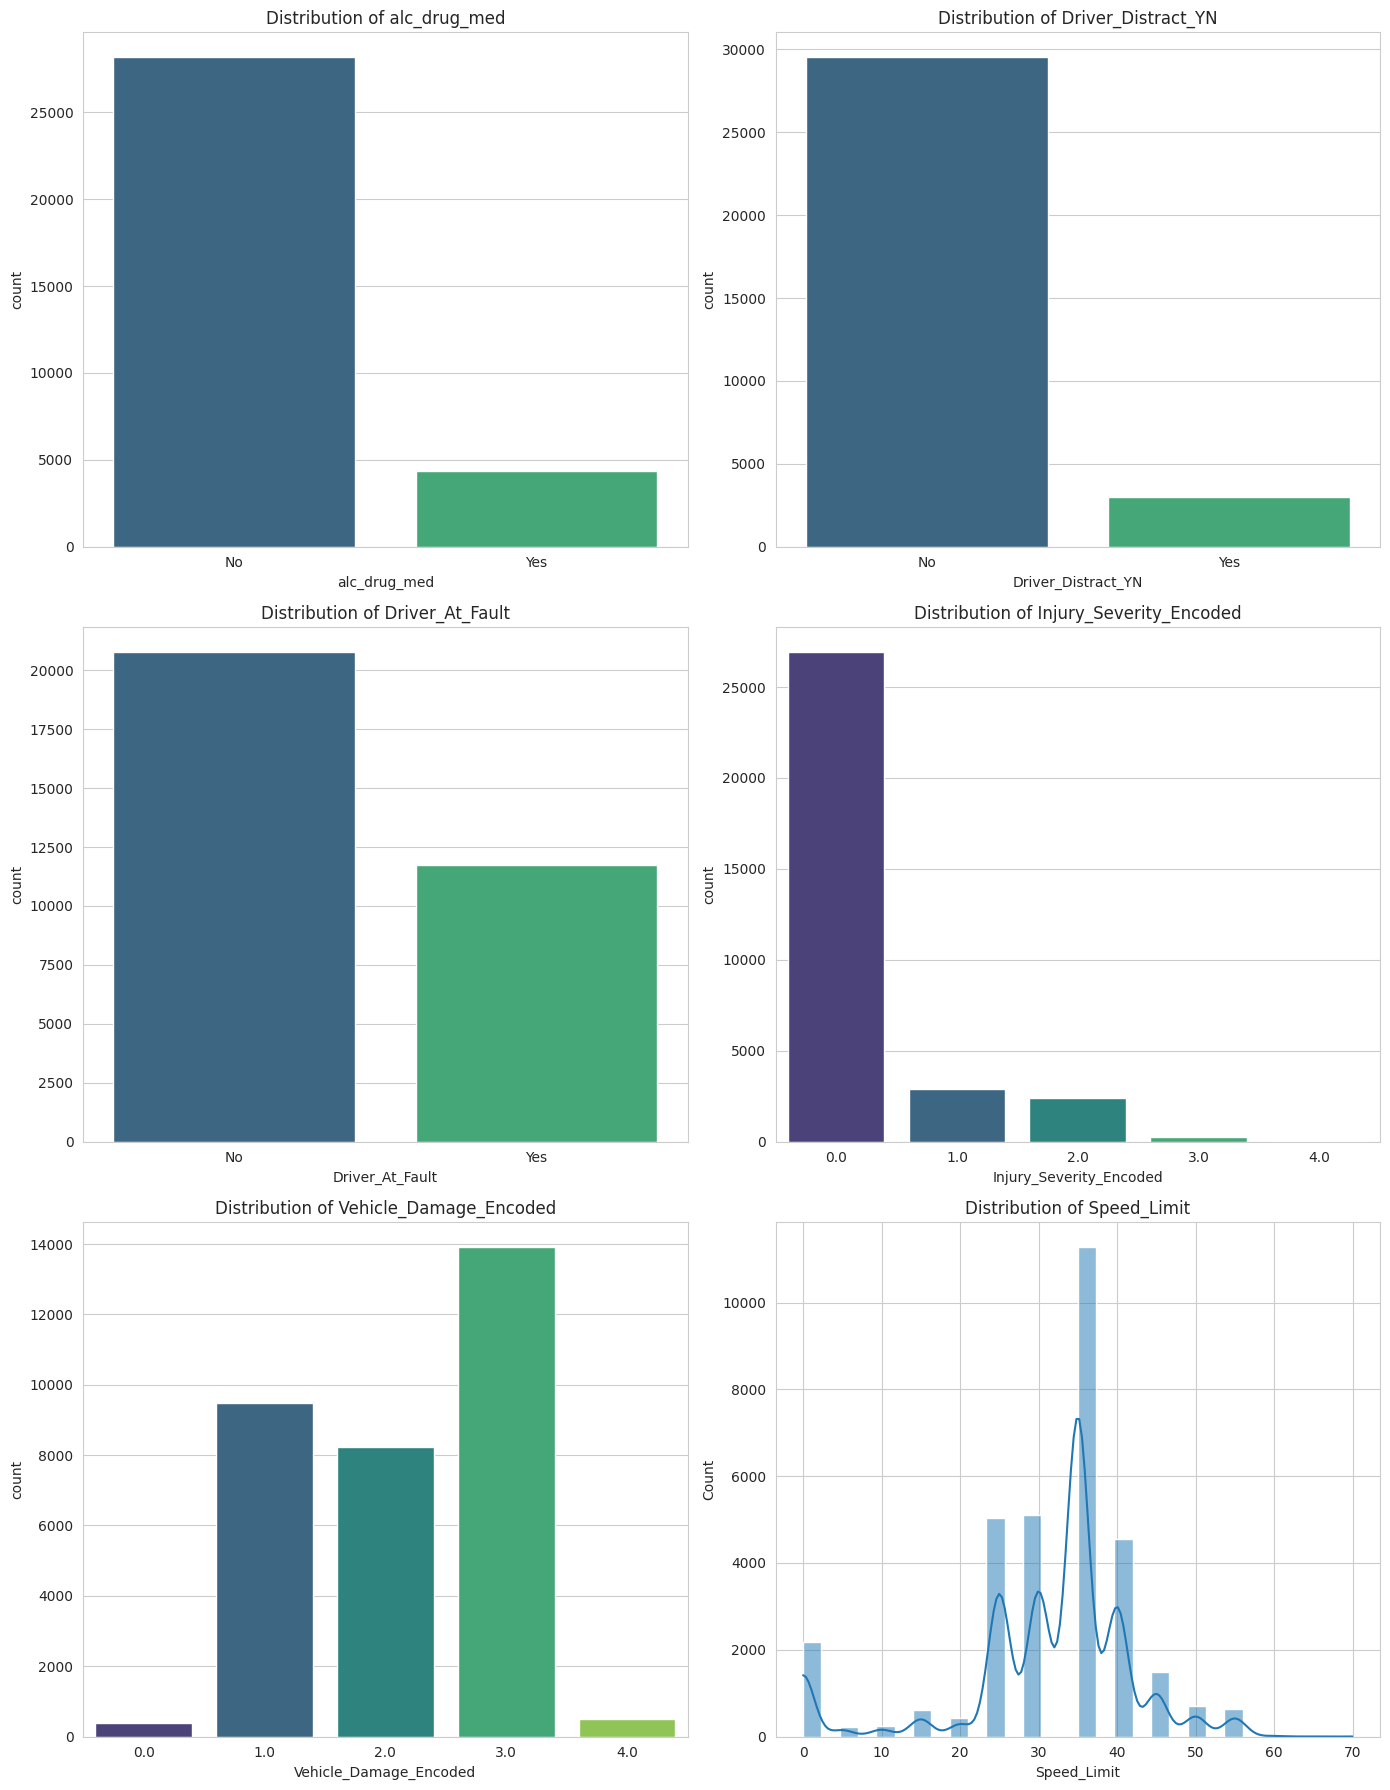

In [ ]:
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(14, 18))
axes = axes.flatten()

categorical_cols = ['alc_drug_med', 'Driver_Distract_YN', 'Driver_At_Fault']
ordinal_cols = ['Injury_Severity_Encoded', 'Vehicle_Damage_Encoded']
numerical_cols = ['Speed_Limit']

# Plot categorical/ordinal columns
for i, col in enumerate(categorical_cols + ordinal_cols):
    sns.countplot(x=col, data=cleaned_crash_df, ax=axes[i], palette='viridis')
    axes[i].set_title(f'Distribution of {col}')
    if col in ordinal_cols:
        # Ensure integer ticks for encoded ordinal data
        min_val = cleaned_crash_df[col].min()
        max_val = cleaned_crash_df[col].max()
        if pd.notna(min_val) and pd.notna(max_val):
            axes[i].set_xticks(range(int(min_val), int(max_val) + 1))

# Plot numerical column
for i, col in enumerate(numerical_cols):
    sns.histplot(cleaned_crash_df[col], kde=True, ax=axes[len(categorical_cols) + len(ordinal_cols) + i], bins=30)
    axes[len(categorical_cols) + len(ordinal_cols) + i].set_title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

### Bivariate Analysis: Relationships between Variables

#### Relationship with Injury Severity

/tmp/ipykernel_1876/4285614806.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='alc_drug_med', y=target_col_injury, data=cleaned_crash_df, ax=axes[0], palette='pastel')
/tmp/ipykernel_1876/4285614806.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Driver_Distract_YN', y=target_col_injury, data=cleaned_crash_df, ax=axes[1], palette='pastel')
/tmp/ipykernel_1876/4285614806.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Driver_At_Fault', y=target_col_injury, data=cleaned_crash_df, ax=axes[2], palette='pastel')
/tmp/ipyker

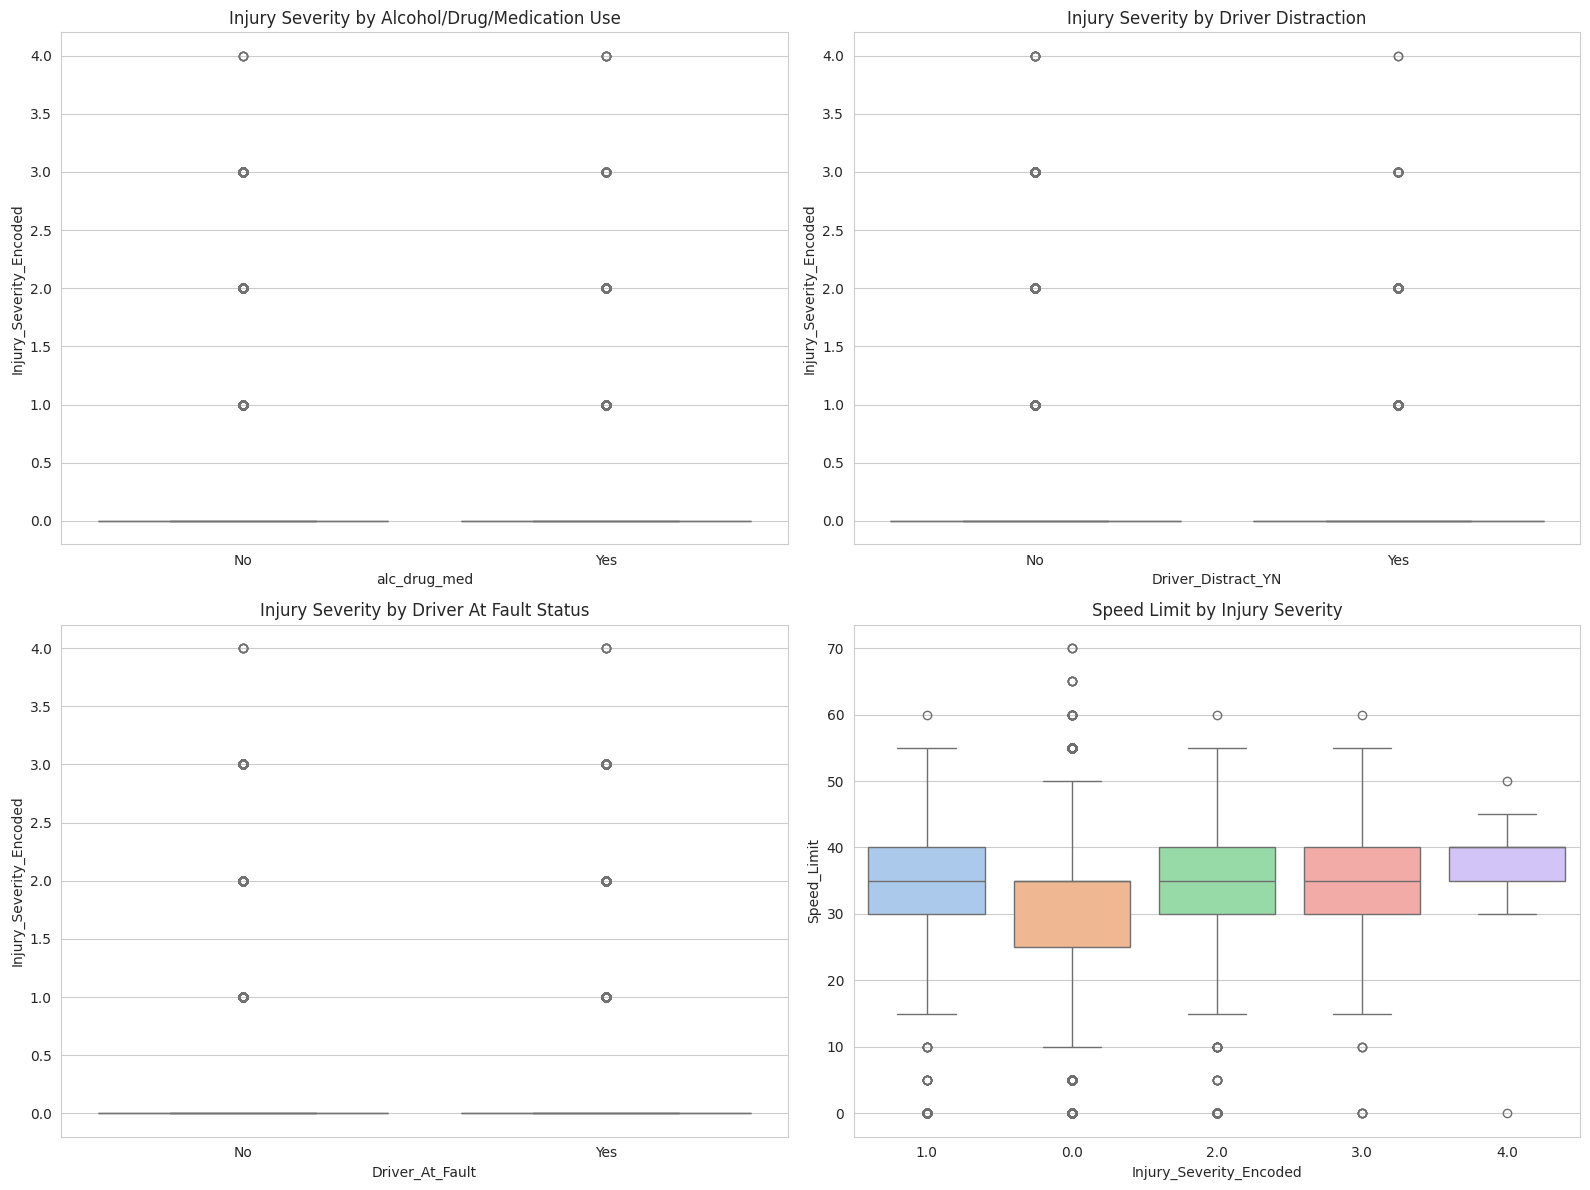

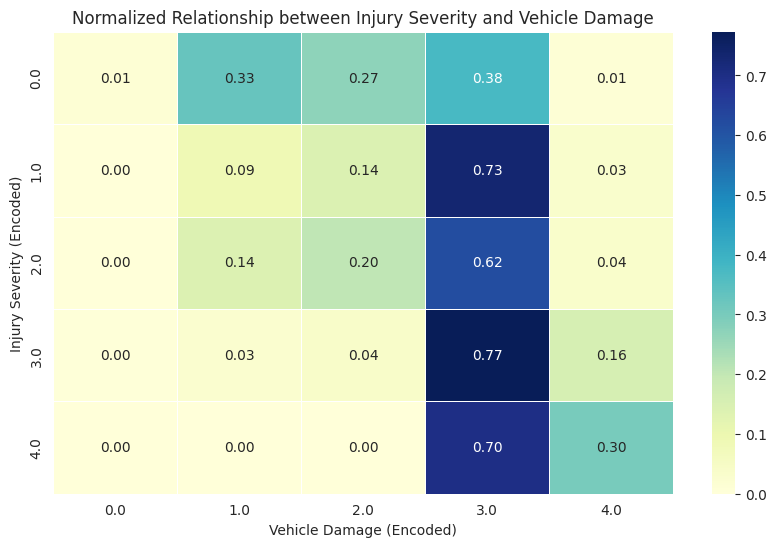

In [ ]:
target_col_injury = 'Injury_Severity_Encoded'
predictor_cols = ['alc_drug_med', 'Driver_Distract_YN', 'Driver_At_Fault',
                  'Vehicle_Damage_Encoded', 'Speed_Limit']

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 12))
axes = axes.flatten()

# Alc_drug_med vs Injury_Severity
sns.boxplot(x='alc_drug_med', y=target_col_injury, data=cleaned_crash_df, ax=axes[0], palette='pastel')
axes[0].set_title('Injury Severity by Alcohol/Drug/Medication Use')

# Driver_Distract_YN vs Injury_Severity
sns.boxplot(x='Driver_Distract_YN', y=target_col_injury, data=cleaned_crash_df, ax=axes[1], palette='pastel')
axes[1].set_title('Injury Severity by Driver Distraction')

# Driver_At_Fault vs Injury_Severity
sns.boxplot(x='Driver_At_Fault', y=target_col_injury, data=cleaned_crash_df, ax=axes[2], palette='pastel')
axes[2].set_title('Injury Severity by Driver At Fault Status')

# Speed_Limit vs Injury_Severity
sns.boxplot(x=cleaned_crash_df[target_col_injury].astype(str), y='Speed_Limit', data=cleaned_crash_df, ax=axes[3], palette='pastel')
axes[3].set_title('Speed Limit by Injury Severity')
axes[3].set_xlabel('Injury_Severity_Encoded')

plt.tight_layout()
plt.show()

# Injury Severity vs Vehicle Damage (both ordinal)
plt.figure(figsize=(10, 6))
sns.heatmap(pd.crosstab(cleaned_crash_df[target_col_injury], cleaned_crash_df['Vehicle_Damage_Encoded'], normalize='index'),
            annot=True, cmap='YlGnBu', fmt='.2f', linewidths=.5)
plt.title('Normalized Relationship between Injury Severity and Vehicle Damage')
plt.ylabel('Injury Severity (Encoded)')
plt.xlabel('Vehicle Damage (Encoded)')
plt.show()

#### Relationship with Vehicle Damage

/tmp/ipykernel_1876/1064753352.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='alc_drug_med', y=target_col_damage, data=cleaned_crash_df, ax=axes[0], palette='coolwarm')
/tmp/ipykernel_1876/1064753352.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Driver_Distract_YN', y=target_col_damage, data=cleaned_crash_df, ax=axes[1], palette='coolwarm')
/tmp/ipykernel_1876/1064753352.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Driver_At_Fault', y=target_col_damage, data=cleaned_crash_df, ax=axes[2], palette='coolwarm')
/tmp/

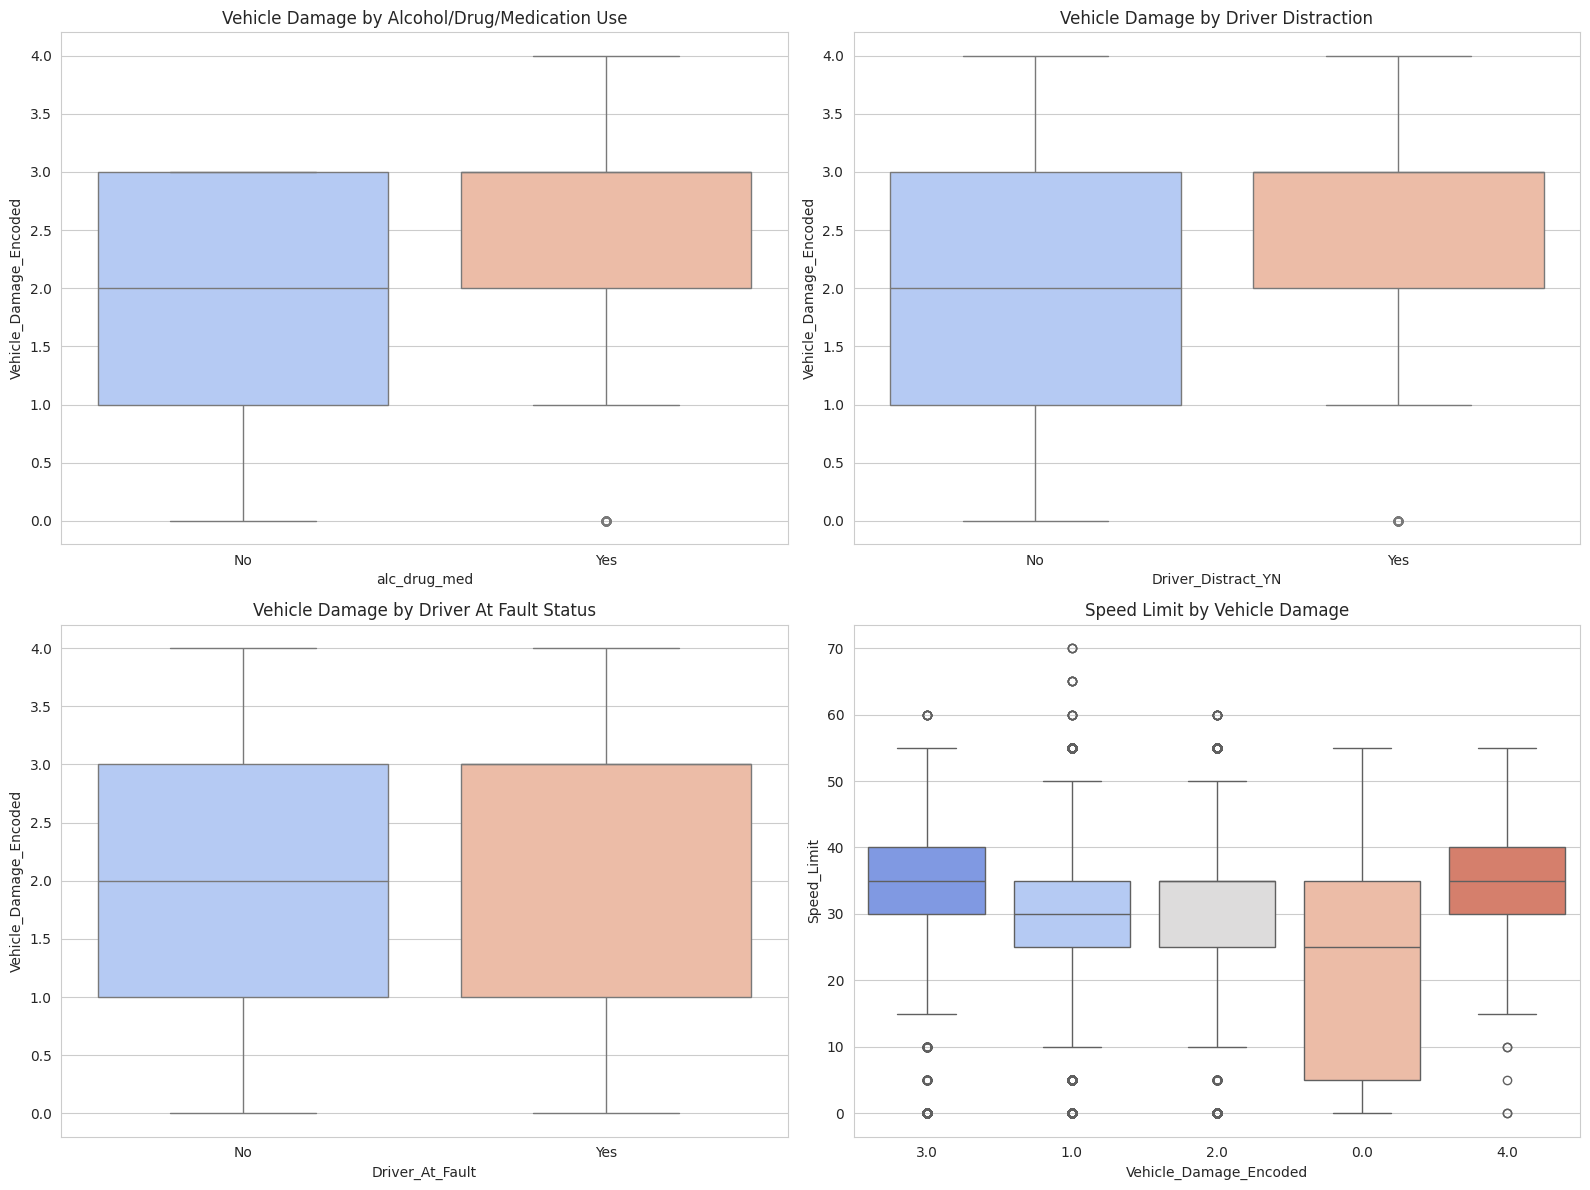

In [ ]:
target_col_damage = 'Vehicle_Damage_Encoded'
predictor_cols = ['alc_drug_med', 'Driver_Distract_YN', 'Driver_At_Fault',
                  'Speed_Limit'] # Injury_Severity_Encoded already covered

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 12))
axes = axes.flatten()

# Alc_drug_med vs Vehicle_Damage
sns.boxplot(x='alc_drug_med', y=target_col_damage, data=cleaned_crash_df, ax=axes[0], palette='coolwarm')
axes[0].set_title('Vehicle Damage by Alcohol/Drug/Medication Use')

# Driver_Distract_YN vs Vehicle_Damage
sns.boxplot(x='Driver_Distract_YN', y=target_col_damage, data=cleaned_crash_df, ax=axes[1], palette='coolwarm')
axes[1].set_title('Vehicle Damage by Driver Distraction')

# Driver_At_Fault vs Vehicle_Damage
sns.boxplot(x='Driver_At_Fault', y=target_col_damage, data=cleaned_crash_df, ax=axes[2], palette='coolwarm')
axes[2].set_title('Vehicle Damage by Driver At Fault Status')

# Speed_Limit vs Vehicle_Damage
sns.boxplot(x=cleaned_crash_df[target_col_damage].astype(str), y='Speed_Limit', data=cleaned_crash_df, ax=axes[3], palette='coolwarm')
axes[3].set_title('Speed Limit by Vehicle Damage')
axes[3].set_xlabel('Vehicle_Damage_Encoded')

plt.tight_layout()
plt.show()

### Correlation Matrix

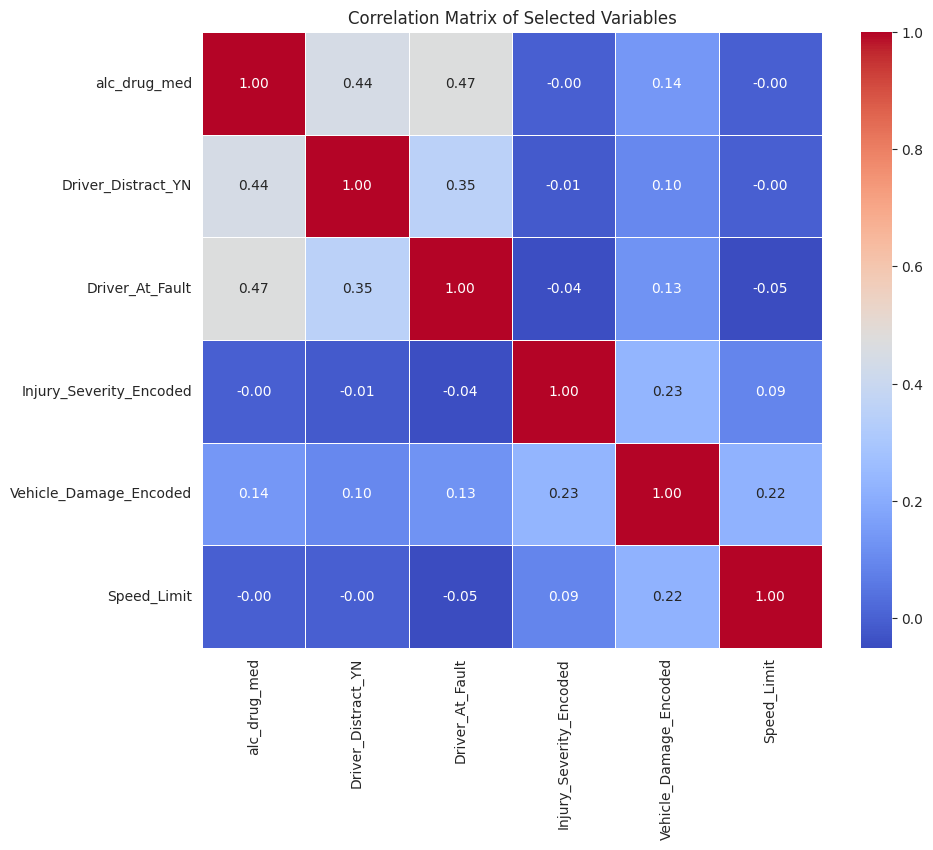

In [ ]:
# For correlation, ensure all variables are numerical.
# 'alc_drug_med', 'Driver_Distract_YN', 'Driver_At_Fault' need to be encoded if not already.
# From previous cells, X contains the encoded versions. Let's use LabelEncoder again for consistency
# directly on the `cleaned_crash_df` for these specific columns if they are not yet numerical.

correlation_df = cleaned_crash_df[eda_cols].copy()

# Re-encode categorical columns for correlation if they are still objects in `correlation_df`
le = LabelEncoder()
for col in ['alc_drug_med', 'Driver_Distract_YN', 'Driver_At_Fault']:
    if correlation_df[col].dtype == 'object':
        correlation_df[col] = le.fit_transform(correlation_df[col])

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Selected Variables')
plt.show()

### Suggestion for Regression Analysis Variables

Based on the exploratory analysis, here are some suggestions for outcome and predictor variables for regression analysis:

**Potential Outcome Variables (Dependent Variables):**

*   **`Injury_Severity_Encoded`**: This is an ordinal variable, making it suitable for ordinal regression or a classification task (if treated as categories).
*   **`Vehicle_Damage_Encoded`**: This is also an ordinal variable, similarly suitable for ordinal regression or classification.

**Potential Predictor Variables (Independent Variables):**

*   **`Speed_Limit`**: Shows a clear relationship with both injury severity and vehicle damage, making it a strong continuous predictor.
*   **`Driver_At_Fault`**: This binary variable (encoded as 0/1) likely has a significant impact on injury severity and vehicle damage.
*   **`alc_drug_med`**: This binary variable (encoded as 0/1) can be a factor contributing to accident outcomes.
*   **`Driver_Distract_YN`**: This binary variable (encoded as 0/1) can also be a significant predictor.

**Possible Regression Models:**

1.  **Predicting `Injury_Severity_Encoded` (Ordinal Regression / Classification):**
    *   **Predictors:** `Speed_Limit`, `Driver_At_Fault`, `alc_drug_med`, `Driver_Distract_YN`, `Vehicle_Damage_Encoded` (if damage is considered a precursor/indicator rather than a simultaneous outcome).

2.  **Predicting `Vehicle_Damage_Encoded` (Ordinal Regression / Classification):**
    *   **Predictors:** `Speed_Limit`, `Driver_At_Fault`, `alc_drug_med`, `Driver_Distract_YN`, `Injury_Severity_Encoded` (if injury is considered an outcome that correlates with damage).

**Note:** For classification models (e.g., Logistic Regression for binary outcomes, or multinomial/ordinal classification for multi-class ordinal outcomes), `Injury_Severity_Encoded` and `Vehicle_Damage_Encoded` can be treated as target classes.

### LabelEncoder Mappings (with Mode Imputation)  
For comparison, keep a dataset where NaN values are replaced by the column mode.  

Verify the mappings after mode imputation,  
as `LabelEncoder` was re-fit.

In [ ]:
print("Mapping for Features (X_mode):")
temp_le_mode = LabelEncoder()
for col_name in ['alc_drug_med', 'Driver_Distract_YN']:
    # Use unique values from the processed_crash_df_mode since NaNs are filled
    unique_values_mode = processed_crash_df_mode[col_name].unique()
    temp_le_mode.fit(unique_values_mode)
    print(f"  {col_name}: {list(zip(temp_le_mode.classes_, range(len(temp_le_mode.classes_))))}")

print("\nMapping for Target Variable (y_mode - Driver_At_Fault):")
print(f"  Driver_At_Fault: {list(zip(le_y_mode.classes_, range(len(le_y_mode.classes_))))}")

Mapping for Features (X_mode):
  alc_drug_med: [('No', 0), ('Yes', 1)]
  Driver_Distract_YN: [('No', 0), ('Yes', 1)]

Mapping for Target Variable (y_mode - Driver_At_Fault):
  Driver_At_Fault: [('No', 0), ('Yes', 1)]


Comparing Evaluations of both models:  

| Model                  | MSE   | R^2    | Accuracy Score |
|:-----------------------|:------|:-------|:---------------|
| NaN rows dropped       | 0.220 | 0.040  | 0.780          |
| NaN replaced with mode | 0.355 | -0.421 | 0.645          |

For NaN rows dropped, R^2 is almost 0, so the model's predictions do not approximate the true values.

For NaN replaced with mode, a negative R² means the model performs worse than no model at all.  




Ignore
####AI use tracker:  
 - For Injury_Severity, code "No Apparent Injury as 0, "Suspected Minor Injury"  as 1, "Possible Injury" as 2, "Suspected Serious Injury" as 3, and "Fatal Injury" as 4.

 - For Vehicle_Damange, code 'Vehicle Not at Scene' as "NaN", 'No Damage' as 0, 'Superficial' as 1,  'Functional'  as 2, 'Disabling'  as 3, and 'Destroyed' as 4.  

 - (Re LabelEncoder):
How do I know what integer representation was assigned to which string value?
What happens to the NaN values?  

- Do not fill in with mode. If any of the three variables in question from the row are NaN,
do not use data from that row in the analysis.

- Perform exploratory analysis on the columns ['alc_drug_med','Driver_Distract_YN', 'Driver_At_Fault', "Injury_Severity_Encoded",
                 "Vehicle_Damage_Encoded", "Speed_Limit"].  Look for associations, correlations.  Suggest variables that would make good outcome and predictor variables in regression analysis.
